In [10]:
import pandas as pd
import numpy as np

# Synthetic Housing Dataset Generator
np.random.seed(42)
n = 250

area = np.random.normal(1800, 500, n).astype(int)
rooms = np.random.randint(1, 6, n)
age = np.random.randint(0, 30, n)
location = np.random.choice(['Suburbs', 'Downtown', 'Rural'], n)

# Price baseline formula with random noise
price = (area * 150) + (rooms * 25000) - (age * 1200) + np.random.normal(0, 25000, n)
price = np.where(location == 'Downtown', price + 80000, price)
price = np.where(location == 'Rural', price - 40000, price)

df_housing = pd.DataFrame({
    'Area_SqFt': area,
    'Bedrooms': rooms,
    'Age_Years': age,
    'Location': location,
    'Price': np.round(price, -2)
})

# Missing values introduce karna EDA test ke liye
df_housing.loc[5:10, 'Area_SqFt'] = np.nan

df_housing.to_csv('housing_dataset.csv', index=False)
print("Dataset 'housing_dataset.csv' successfully created.")

Dataset 'housing_dataset.csv' successfully created.


Shape: (250, 5)

--- Missing Values ---
Area_SqFt    6
Bedrooms     0
Age_Years    0
Location     0
Price        0
dtype: int64

--- Descriptive Statistics ---
           count           mean           std      min       25%       50%  \
Area_SqFt  244.0    1794.717213    484.834678    490.0    1446.5    1829.5   
Bedrooms   250.0       3.148000      1.471993      1.0       2.0       3.0   
Age_Years  250.0      14.776000      8.806135      0.0       7.0      15.0   
Price      250.0  341332.800000  98224.767467  65900.0  274225.0  340950.0   

                75%       max  
Area_SqFt    2087.0    3726.0  
Bedrooms        4.0       5.0  
Age_Years      22.0      29.0  
Price      404075.0  596700.0  


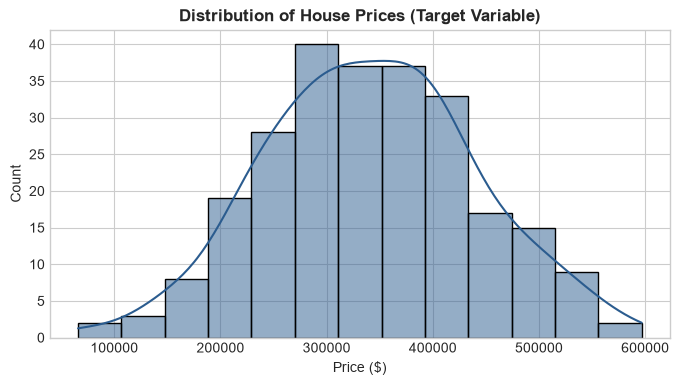

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Load dataset
df = pd.read_csv('housing_dataset.csv')

print("Shape:", df.shape)
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe().T)

# Target Variable Distribution Plot
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='#2b5c8f')
plt.title('Distribution of House Prices (Target Variable)', fontsize=12, fontweight='bold')
plt.xlabel('Price ($)')
plt.show()

In [12]:
# Impute missing Area values with median
df['Area_SqFt'] = df['Area_SqFt'].fillna(df['Area_SqFt'].median())

# One-Hot Encoding for categorical feature 'Location'
df_encoded = pd.get_dummies(df, columns=['Location'], drop_first=True, dtype=int)

df_encoded.head()

,Area_SqFt,Bedrooms,Age_Years,Price,Location_Rural,Location_Suburbs
0,2048.0,5,15,340700.0,1,0
1,1730.0,5,28,398100.0,0,1
2,2123.0,1,12,293600.0,1,0
3,2561.0,5,13,496100.0,0,1
4,1682.0,5,2,452600.0,0,0


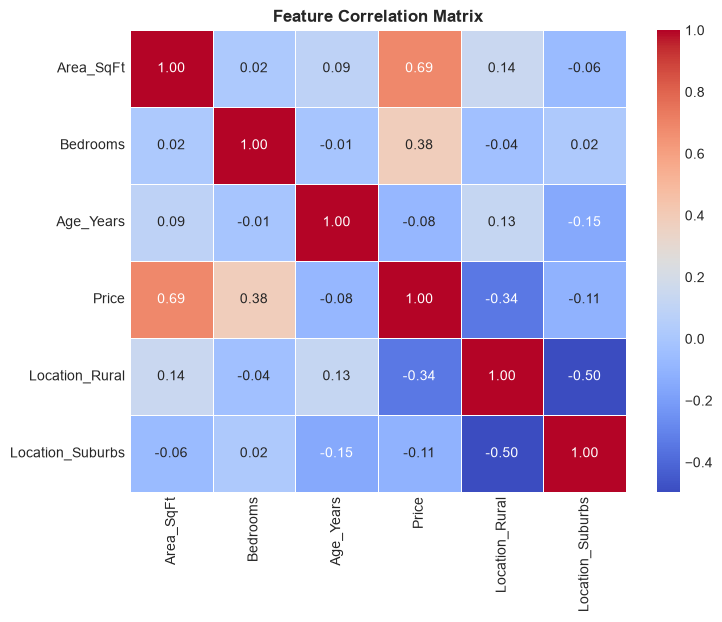

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & Target definition
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== MODEL PERFORMANCE METRICS ===")
print(f"Mean Squared Error (MSE) : {mse:,.2f}")
print(f"Root Mean Squared Error  : ${rmse:,.2f}")
print(f"R² Score                 : {r2:.4f}")

=== MODEL PERFORMANCE METRICS ===
Mean Squared Error (MSE) : 1,434,261,114.21
Root Mean Squared Error  : $37,871.64
R² Score                 : 0.8301


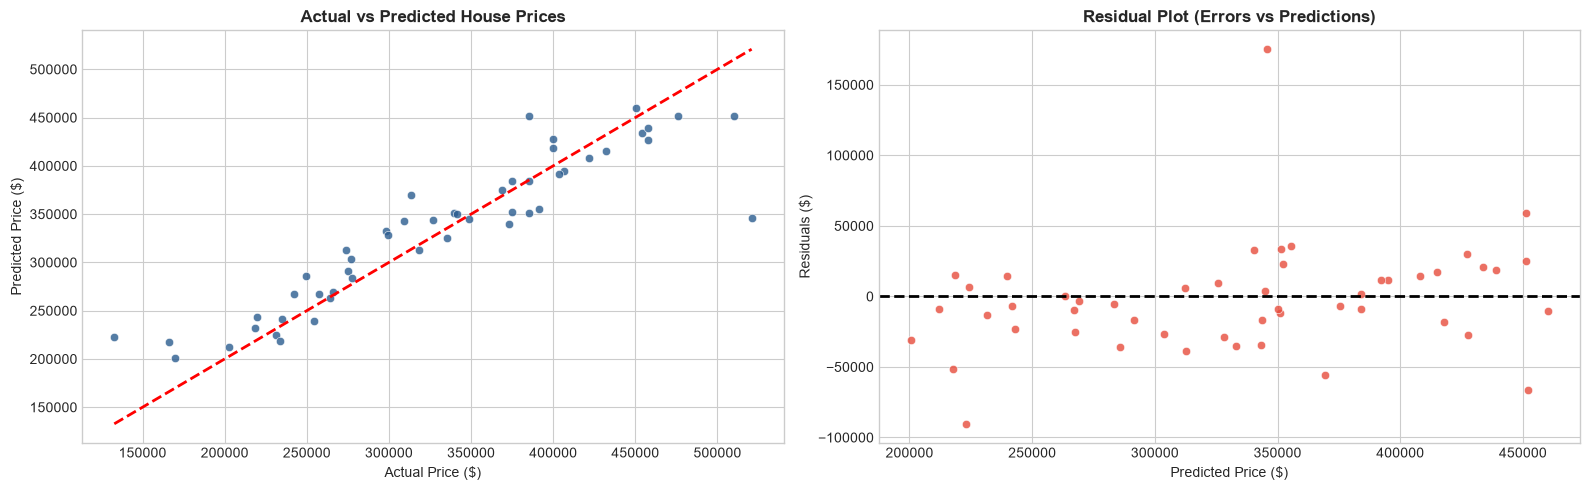

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Actual vs Predicted Prices
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0], color='#2b5c8f', alpha=0.8)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted House Prices', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')

# Plot 2: Residual Plot
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals, ax=axes[1], color='#e74c3c', alpha=0.8)
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residual Plot (Errors vs Predictions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')

plt.tight_layout()
plt.show()

In [17]:
from sklearn.linear_model import Ridge, Lasso

# Coefficients DataFrame
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear Regression Coef': model.coef_
})

# Train Regularized Models
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=100.0).fit(X_train, y_train)

coef_df['Ridge Coef'] = ridge.coef_
coef_df['Lasso Coef'] = lasso.coef_

print("=== FEATURE COEFFICIENTS COMPARISON ===")
print(coef_df.to_string(index=False))

=== FEATURE COEFFICIENTS COMPARISON ===
         Feature  Linear Regression Coef     Ridge Coef     Lasso Coef
       Area_SqFt              151.611649     151.278734     151.555253
        Bedrooms            23402.512469   23389.152761   23363.158454
       Age_Years            -1371.343790   -1359.703463   -1366.764807
  Location_Rural          -126382.293555 -121616.807391 -125491.603363
Location_Suburbs           -80223.464894  -76003.565523  -79289.676770
